# 17 — Publication figures and manuscript assets

This notebook collects all versioned publication outputs, generates manuscript-ready figures, and writes claim gates based on actual available evidence.

## Setup and asset index

In [1]:

from pathlib import Path
import os
import sys
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Edit this path only if your project has moved.
PROJECT_ROOT = Path(
    os.environ.get(
        "LATENT_MANIFOLD_PROJECT_ROOT",
        r"C:\Users\Peter\Documents\projects\NeuroAI\latent-manifold-v1-natural-movies",
    )
).resolve()

SRC_DIR = PROJECT_ROOT / "src"
if not PROJECT_ROOT.exists():
    raise FileNotFoundError(f"PROJECT_ROOT does not exist: {PROJECT_ROOT}")
if not SRC_DIR.exists():
    raise FileNotFoundError(f"src directory does not exist: {SRC_DIR}")
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))
os.chdir(PROJECT_ROOT)

cfg_path = PROJECT_ROOT / "configs" / "publication_upgrade.yaml"
if not cfg_path.exists():
    raise FileNotFoundError(f"Could not find publication config: {cfg_path}")
with cfg_path.open("r", encoding="utf-8") as f:
    pub_cfg = yaml.safe_load(f)
cfg = pub_cfg

# Versioned namespace. This prevents accidental overwriting of older publication outputs.
PUBLICATION_RUN_LABEL = os.environ.get("PUBLICATION_RUN_LABEL", "publication_upgrade_v3_multisession")
ALLOW_CANONICAL_PUBLICATION_WRITE = os.environ.get("ALLOW_CANONICAL_PUBLICATION_WRITE", "0") == "1"
if PUBLICATION_RUN_LABEL == "publication_upgrade" and not ALLOW_CANONICAL_PUBLICATION_WRITE:
    raise RuntimeError(
        "Refusing to write into the canonical publication_upgrade namespace. "
        "Use a versioned PUBLICATION_RUN_LABEL or set ALLOW_CANONICAL_PUBLICATION_WRITE=1 intentionally."
    )

class ProjectPaths:
    def __init__(self, root: Path, run_label: str):
        self.root = root
        self.configs_dir = root / "configs"
        self.data_dir = root / "data"
        self.external_dir = root / "data" / "external"
        self.raw_dir = root / "data" / "raw"
        self.interim_dir = root / "data" / "interim"
        self.processed_dir = root / "data" / "processed"
        self.versioned_processed_dir = self.processed_dir / run_label
        self.reports_dir = root / "reports"
        self.tables_dir = root / "reports" / "tables"
        self.figures_dir = root / "reports" / "figures"
        self.html_dir = root / "reports" / "html"
        self.publication_tables_dir = root / "reports" / "tables" / run_label
        self.publication_figures_dir = root / "reports" / "figures" / run_label
        self.manuscript_dir = root / "manuscript" / "top_journal_scaffold"
        for d in [
            self.versioned_processed_dir,
            self.publication_tables_dir,
            self.publication_figures_dir,
            self.manuscript_dir,
        ]:
            d.mkdir(parents=True, exist_ok=True)

paths = ProjectPaths(PROJECT_ROOT, PUBLICATION_RUN_LABEL)

def save_table(df, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False)
    return path

def save_figure(fig, path, dpi=300):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    return path

# Upgrade helper functions shipped with this patch.
from v1_manifold_publication.multisession_core import (
    build_multisession_asset_index,
    candidate_feature_files,
    choose_best_feature_table,
    ready_sessions,
    movie_feature_targets,
    empirical_null_summary,
    safe_read_csv,
    safe_table_index,
    claim_gate_from_assets,
    ensure_table,
)

metadata_path = paths.external_dir / "allen_v1_natural_movie_experiments.csv"
asset_index = build_multisession_asset_index(paths, metadata_path=metadata_path)
save_table(asset_index, paths.publication_tables_dir / "00_multisession_asset_index.csv")

print("Using PROJECT_ROOT:", PROJECT_ROOT)
print("Publication run label:", PUBLICATION_RUN_LABEL)
print("Publication tables:", paths.publication_tables_dir)
print("Publication figures:", paths.publication_figures_dir)
print("Versioned processed dir:", paths.versioned_processed_dir)
display(asset_index)


Using PROJECT_ROOT: C:\Users\Peter\Documents\projects\NeuroAI\latent-manifold-v1-natural-movies
Publication run label: publication_upgrade_v3_multisession
Publication tables: C:\Users\Peter\Documents\projects\NeuroAI\latent-manifold-v1-natural-movies\reports\tables\publication_upgrade_v3_multisession
Publication figures: C:\Users\Peter\Documents\projects\NeuroAI\latent-manifold-v1-natural-movies\reports\figures\publication_upgrade_v3_multisession
Versioned processed dir: C:\Users\Peter\Documents\projects\NeuroAI\latent-manifold-v1-natural-movies\data\processed\publication_upgrade_v3_multisession


,session_id,feature_file,feature_shape,tensor_file,embedding_file,embedding_names,embedding_shapes,has_features,has_tensor,has_embeddings,ready_for_latent_decoding,ready_for_population_encoding,ready_for_full_neural_analysis
0,500855614,C:\Users\Peter\Documents\projects\NeuroAI\late...,"(900, 105)",C:\Users\Peter\Documents\projects\NeuroAI\late...,C:\Users\Peter\Documents\projects\NeuroAI\late...,"pca,pca_full,umap,isomap,cebra","pca:(900, 3);pca_full:(900, 20);umap:(900, 3);...",True,True,True,True,True,True
1,500964514,C:\Users\Peter\Documents\projects\NeuroAI\late...,"(900, 105)",C:\Users\Peter\Documents\projects\NeuroAI\late...,C:\Users\Peter\Documents\projects\NeuroAI\late...,"pca,pca_full,umap,isomap","pca:(900, 3);pca_full:(900, 20);umap:(900, 3);...",True,True,True,True,True,True
2,501271265,C:\Users\Peter\Documents\projects\NeuroAI\late...,"(900, 105)",C:\Users\Peter\Documents\projects\NeuroAI\late...,C:\Users\Peter\Documents\projects\NeuroAI\late...,"pca,pca_full,umap,isomap","pca:(900, 3);pca_full:(900, 20);umap:(900, 3);...",True,True,True,True,True,True


## Publication table index

In [2]:

table_index = safe_table_index(paths.publication_tables_dir)
save_table(table_index, paths.publication_tables_dir / "17_publication_table_index.csv")
display(table_index)


,table,rows,columns,empty,error
0,00_multisession_asset_index.csv,3,13,False,
1,12c_asset_generation_command_run_logs.csv,4,5,False,
2,12c_missing_embedding_generation_status.csv,2,7,False,
3,12c_missing_multisession_assets_todo.csv,4,4,False,
4,12c_multisession_asset_index.csv,3,13,False,
...,...,...,...,...,...
70,16_cross_session_alignment_group_summary.csv,4,4,False,
71,16_cross_session_claim_gate.csv,2,4,False,
72,16_pairwise_cross_session_manifold_alignment.csv,12,9,False,
73,16_pairwise_cross_session_manifold_alignment_s...,1,4,False,


## Figure: latent feature decoding by representation

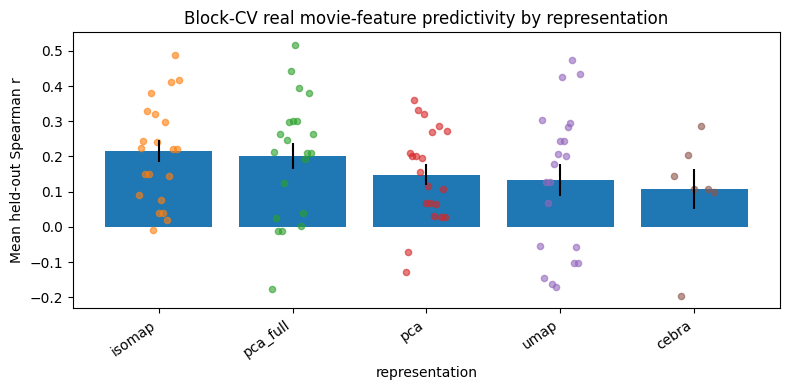

In [3]:

from v1_manifold_publication.plotting import bar_with_points, heatmap, savefig

summary_path = paths.publication_tables_dir / "13_latent_feature_decoding_blockcv_summary.csv"
dec = safe_read_csv(summary_path)

if dec.empty:
    print("No latent decoding summary available.")
else:
    y_col = "spearman_r_mean" if "spearman_r_mean" in dec.columns else ("r2_mean" if "r2_mean" in dec.columns else None)
    if y_col is None:
        print("No suitable decoding metric column found:", list(dec.columns))
    else:
        ylabel = "Mean held-out Spearman r" if y_col == "spearman_r_mean" else "Mean held-out R²"
        fig = bar_with_points(
            dec,
            x="representation",
            y=y_col,
            title="Block-CV real movie-feature predictivity by representation",
            ylabel=ylabel,
        )
        savefig(fig, paths.publication_figures_dir / f"17_blockcv_feature_predictivity_by_representation_{y_col}.png")
        plt.show()


## Figure: feature hierarchy encoding

In [4]:

ranked_path = paths.publication_tables_dir / "13_feature_hierarchy_encoding_ranked_summary.csv"
ranked = safe_read_csv(ranked_path)

if ranked.empty or "population_spearman_r_mean" not in ranked.columns:
    print("No feature hierarchy ranked summary available.")
else:
    best = (
        ranked
        .sort_values("population_spearman_r_mean", ascending=False)
        .groupby("feature_group", as_index=False)
        .first()
        .sort_values("population_spearman_r_mean", ascending=False)
    )
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(best["feature_group"], best["population_spearman_r_mean"])
    ax.set_xlabel("Stimulus feature group")
    ax.set_ylabel("Mean held-out population Spearman r")
    ax.set_title("Feature hierarchy encoding of V1 population activity")
    ax.tick_params(axis="x", rotation=30)
    fig.tight_layout()
    save_figure(fig, paths.publication_figures_dir / "17_feature_hierarchy_encoding_summary.png")
    plt.show()


No feature hierarchy ranked summary available.


## Figure: geometry summaries

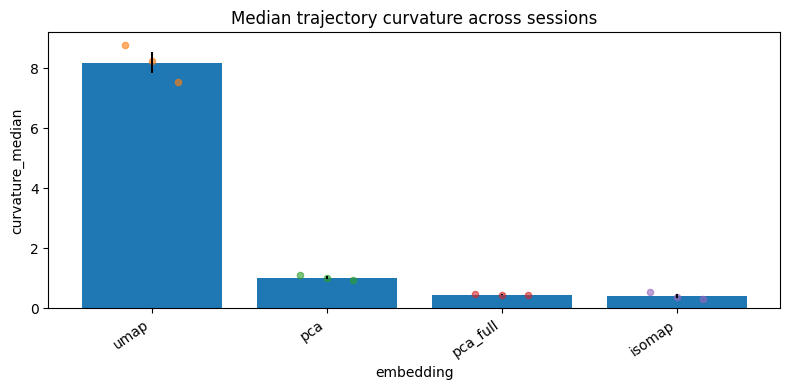

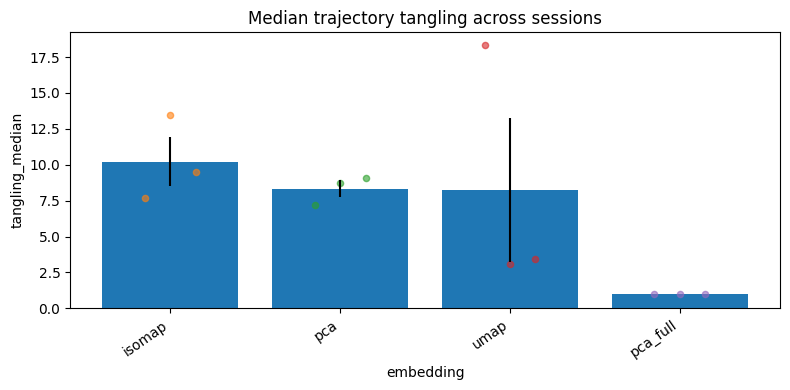

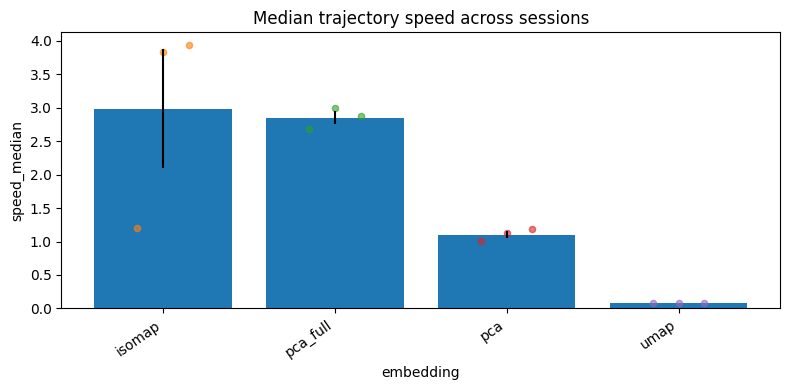

In [5]:

geom_path = paths.publication_tables_dir / "14_geometry_with_session_metadata.csv"
geom = safe_read_csv(geom_path)

if geom.empty:
    print("No geometry metadata table available.")
else:
    for y_col, title, fname in [
        ("curvature_median", "Median trajectory curvature across sessions", "17_geometry_curvature_by_embedding.png"),
        ("tangling_median", "Median trajectory tangling across sessions", "17_geometry_tangling_by_embedding.png"),
        ("speed_median", "Median trajectory speed across sessions", "17_geometry_speed_by_embedding.png"),
    ]:
        if y_col in geom.columns:
            fig = bar_with_points(geom, x="embedding", y=y_col, title=title, ylabel=y_col)
            savefig(fig, paths.publication_figures_dir / fname)
            plt.show()


## Figure: brain-model alignment heatmaps

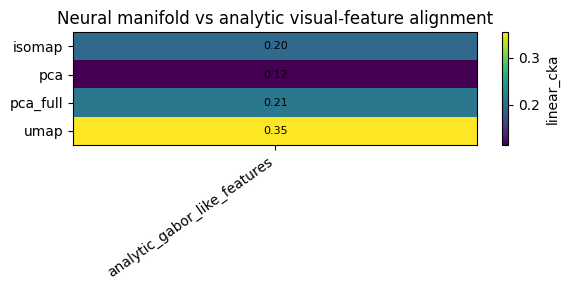

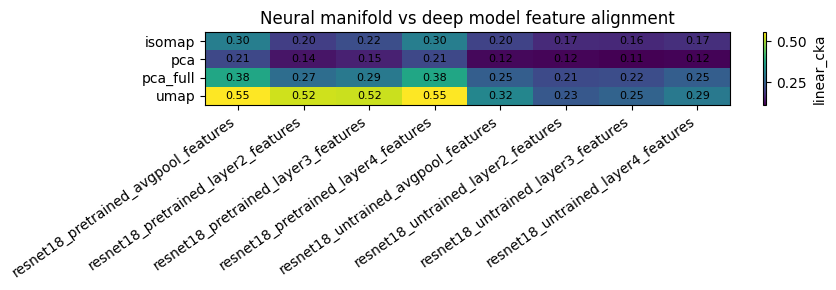

In [7]:
align_path = paths.publication_tables_dir / "15_brain_model_alignment_analytic_features.csv"
align = safe_read_csv(align_path)

if align.empty:
    print("No analytic brain-model alignment table available.")
else:
    if all(c in align.columns for c in ["neural_representation", "model_representation", "linear_cka"]):

        analytic_heat = (
            align.groupby(
                ["neural_representation", "model_representation"],
                as_index=False,
            )["linear_cka"]
            .mean()
        )

        fig = heatmap(
            analytic_heat,
            index="neural_representation",
            columns="model_representation",
            values="linear_cka",
            title="Neural manifold vs analytic visual-feature alignment",
        )

        savefig(
            fig,
            paths.publication_figures_dir / "17_brain_model_alignment_heatmap.png",
        )

        plt.show()

deep_path = paths.publication_tables_dir / "15_brain_model_alignment_deep_features.csv"
deep = safe_read_csv(deep_path)

if not deep.empty and all(c in deep.columns for c in ["neural_representation", "model_representation", "linear_cka"]):

    deep_heat = (
        deep.groupby(
            ["neural_representation", "model_representation"],
            as_index=False,
        )["linear_cka"]
        .mean()
    )

    fig = heatmap(
        deep_heat,
        index="neural_representation",
        columns="model_representation",
        values="linear_cka",
        title="Neural manifold vs deep model feature alignment",
    )

    savefig(
        fig,
        paths.publication_figures_dir / "17_deep_model_alignment_heatmap.png",
    )

    plt.show()

## Figure: cross-session manifold alignment, if available

In [ ]:

alignment = safe_read_csv(paths.publication_tables_dir / "16_pairwise_cross_session_manifold_alignment.csv")
if alignment.empty:
    print("No cross-session alignment table available yet.")
elif "mean_cka_r" in alignment.columns:
    fig = bar_with_points(
        alignment,
        x="embedding" if "embedding" in alignment.columns else "same_layer",
        y="mean_cka_r",
        title="Cross-session manifold alignment",
        ylabel="Mean CKA/r alignment",
    )
    savefig(fig, paths.publication_figures_dir / "17_cross_session_alignment_summary.png")
    plt.show()

## Final claim-gate table

In [9]:

gates = claim_gate_from_assets(asset_index, paths.publication_tables_dir)
save_table(gates, paths.publication_tables_dir / "17_final_claim_gate_table.csv")

gate_counts = gates["status"].value_counts().rename_axis("status").reset_index(name="n_claims")
save_table(gate_counts, paths.publication_tables_dir / "17_final_claim_gate_counts.csv")

interpretation_rows = []
for _, row in gates.iterrows():
    interpretation_rows.append({
        "claim": row["claim"],
        "status": row["status"],
        "interpretation": (
            "Can be reported as a current result, with appropriately cautious framing."
            if row["status"] == "supported"
            else "Do not present as a main biological conclusion yet; treat as a required publication gate."
        ),
    })
gate_interpretation = pd.DataFrame(interpretation_rows)
save_table(gate_interpretation, paths.publication_tables_dir / "17_final_claim_gate_interpretation.csv")

display(gates)
display(gate_counts)
display(gate_interpretation)


,claim,minimum_evidence,status
0,single-session V1 natural-movie decoding,at least one processed session with real featu...,supported
1,multi-session replication,at least three fully processed sessions with c...,supported
2,layer-specific manifold geometry,at least three represented layers with cell-co...,not_ready
3,deep-model brain alignment,nonempty DNN/ViT alignment and encoding tables...,supported
4,cross-session shared manifold,nonempty cross-session manifold alignment tabl...,supported


,status,n_claims
0,supported,4
1,not_ready,1


,claim,status,interpretation
0,single-session V1 natural-movie decoding,supported,"Can be reported as a current result, with appr..."
1,multi-session replication,supported,"Can be reported as a current result, with appr..."
2,layer-specific manifold geometry,not_ready,Do not present as a main biological conclusion...
3,deep-model brain alignment,supported,"Can be reported as a current result, with appr..."
4,cross-session shared manifold,supported,"Can be reported as a current result, with appr..."


## Manuscript asset index and cautious candidate claims

In [10]:

table_index = safe_table_index(paths.publication_tables_dir)
fig_index = pd.DataFrame([
    {"figure": p.name, "path": str(p), "size_kb": round(p.stat().st_size / 1024, 1)}
    for p in sorted(paths.publication_figures_dir.glob("*.png"))
])

save_table(table_index, paths.publication_tables_dir / "17_publication_table_index.csv")
save_table(fig_index, paths.publication_tables_dir / "17_publication_figure_index.csv")

gates = safe_read_csv(paths.publication_tables_dir / "17_final_claim_gate_table.csv")
supported = gates.query("status == 'supported'")["claim"].tolist() if not gates.empty else []
not_ready = gates.query("status != 'supported'")["claim"].tolist() if not gates.empty else []

claims = []
claims.append("# Candidate manuscript claims after multi-session publication upgrade\n")
claims.append(f"Publication run label: `{PUBLICATION_RUN_LABEL}`.\n")
claims.append(f"Fully ready neural sessions: `{int(asset_index['ready_for_full_neural_analysis'].sum()) if not asset_index.empty else 0}`.\n")
claims.append("\n## Supported claims\n")
if supported:
    for claim in supported:
        claims.append(f"- {claim}\n")
else:
    claims.append("- No main biological claim is fully supported yet.\n")
claims.append("\n## Claims not yet supported\n")
for claim in not_ready:
    claims.append(f"- {claim}\n")
claims.append("\n## Required additions for a top-journal submission\n")
claims.append("- Process and embed at least three sessions with the same preprocessing/embedding pipeline.\n")
claims.append("- Rerun notebooks 13–17 under the same versioned namespace.\n")
claims.append("- Report session-level uncertainty, empirical null controls, noise ceilings, and claim gates.\n")
claims.append("- Add DNN/ViT feature alignment only after extracting actual model activations and matched untrained controls.\n")

claims_path = paths.manuscript_dir / "candidate_claims_after_publication_upgrade.md"
claims_path.parent.mkdir(parents=True, exist_ok=True)
claims_path.write_text("".join(claims), encoding="utf-8")

display(table_index)
display(fig_index)
print("Saved:", claims_path)


,table,rows,columns,empty,error
0,00_multisession_asset_index.csv,3,13,False,
1,12c_asset_generation_command_run_logs.csv,4,5,False,
2,12c_missing_embedding_generation_status.csv,2,7,False,
3,12c_missing_multisession_assets_todo.csv,4,4,False,
4,12c_multisession_asset_index.csv,3,13,False,
...,...,...,...,...,...
74,17_final_claim_gate_counts.csv,2,2,False,
75,17_final_claim_gate_interpretation.csv,5,3,False,
76,17_final_claim_gate_table.csv,5,3,False,
77,17_publication_table_index.csv,75,5,False,


,figure,path,size_kb
0,13_feature_hierarchy_encoding_clean_multisessi...,C:\Users\Peter\Documents\projects\NeuroAI\late...,177.3
1,14_median_curvature_by_embedding.png,C:\Users\Peter\Documents\projects\NeuroAI\late...,86.4
2,14_median_tangling_by_embedding.png,C:\Users\Peter\Documents\projects\NeuroAI\late...,95.1
3,14_multisession_curvature_by_embedding.png,C:\Users\Peter\Documents\projects\NeuroAI\late...,84.9
4,15_resnet18_alignment_heatmap.png,C:\Users\Peter\Documents\projects\NeuroAI\late...,222.0
5,15_resnet18_pretrained_minus_untrained_delta.png,C:\Users\Peter\Documents\projects\NeuroAI\late...,220.8
6,17_blockcv_feature_predictivity_by_representat...,C:\Users\Peter\Documents\projects\NeuroAI\late...,167.3
7,17_brain_model_alignment_heatmap.png,C:\Users\Peter\Documents\projects\NeuroAI\late...,80.9
8,17_deep_model_alignment_heatmap.png,C:\Users\Peter\Documents\projects\NeuroAI\late...,250.1
9,17_geometry_curvature_by_embedding.png,C:\Users\Peter\Documents\projects\NeuroAI\late...,82.7


Saved: C:\Users\Peter\Documents\projects\NeuroAI\latent-manifold-v1-natural-movies\manuscript\top_journal_scaffold\candidate_claims_after_publication_upgrade.md
